<h1 style="color:green;font-size:22px;">Function 1 - Black-Box Optimisation</h1>
<h1 style="color:#0000CD;font-size:19px;">Objective and reading guide</h1>

Function 1 is a two-dimensional black-box objective over the bounded domain $[0,1]^2$. Its analytical form and physical interpretation are unknown. The goal is to **find the input configuration that maximises the observed value of Function 1** under a limited sequential-evaluation budget.

As an illustrative analogy, imagine searching a two-dimensional area for small hidden contamination sources with a detector, where readings may change only near a source. Bayesian optimisation uses each observation to decide where to search next, balancing unexplored areas with promising locations.

The 13 historical queries are grouped into four strategy phases:

1. **Global exploration** of the domain (Weeks 1-4); 
2. **Higher-resolution search** within promising regions (Weeks 5-8);
3. **Local refinement** around the best observations (Weeks 9-11);
4. **Directional refinement** around the strongest local observations (Weeks 12-13).

The modelling and query-selection choices used in each phase are introduced as they become relevant. The notebook focuses on **what changed**, **why it changed**, and **what was learned**. The final section evaluates optimisation performance, predictive robustness, sensitivity and the limitations introduced by researcher intervention.

In [20]:
# Standard libraries
import sys
import warnings
from pathlib import Path

# Numerical computing, data handling and visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

# BBO project root
ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

# BBO project package
from src.config import RANDOM_SEED
from src.data import load_initial_data, extract, update_data, historical_record
from src.search import cartesian_grid, search_region, random_candidates, run_search_strategy
from src.surrogate import build_kernel
from src.acquisition import upper_confidence_bound, expected_improvement, probability_of_improvement

from src.plotting import (
    plot_data_exploration,
    plot_acquisition_2d,
    plot_rbf_surface_3d,
    plot_global_to_local_refinement_2d,
    plot_sequential_query_performance)

from src.validation import (
    sequential_performance,
    kernel_choice_validation,
    fixed_length_scale_validation,
    length_scale_cv_sensitivity,
    cartesian_resolution_sensitivity)

# Notebook Configurations
FUNCTION_ID = 1
warnings.filterwarnings("ignore", category=ConvergenceWarning)

<h1 style="color:#0000CD;font-size:19px;"">1. Initial observations</h1>

**1.1 - Extraction of initial data**

The experiment begins with 10 observations. Before fitting a model, the first task is simply to understand their scale and spatial coverage.<br>
The **incumbent** is the best objective value observed so far. It is the benchmark that every later query tries to improve.

In [21]:
data = load_initial_data(FUNCTION_ID)
inputs, outputs = extract(data)
display(data)

print(f"Initial observations: {len(data)}")
print(f"Initial best: {outputs.max():.6e} at {inputs[np.argmax(outputs)]}")

,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


Initial observations: 10
Initial best: 7.710875e-16 at [0.73102363 0.73299988]


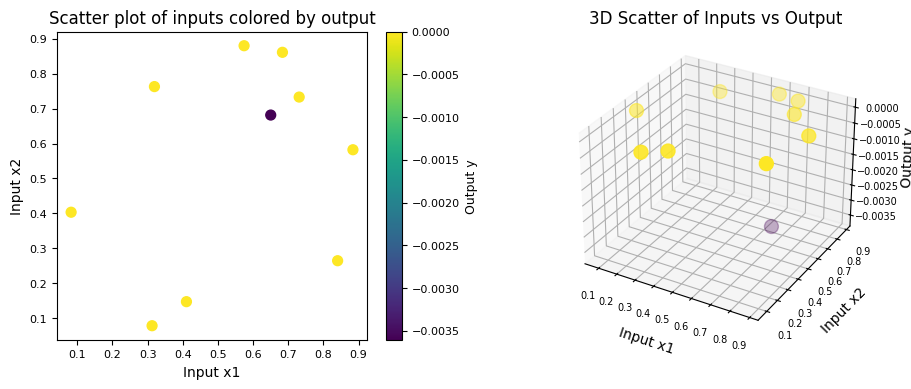

In [22]:
plot_data_exploration(data)

**Interpretation:** Most observed responses are numerically close to zero, while one point is substantially negative. With only 10 observations, this does not tell us whether the rest of the domain is genuinely flat or whether narrow regions of better performance remain unsampled.

That uncertainty motivates an exploratory first phase: rather than immediately searching only around the current best point, the optimisation initially allocates queries to learn more about the wider domain.

**1.2. Model-free geometric exploration benchmark**

Before introducing a statistical model, we construct a simple benchmark. A $50^2$ grid is used to identify the point furthest from the existing observations. This benchmark is useful because the first GP-UCB recommendation can then be compared with a purely geometric exploration rule.

In [23]:
X_grid_50 = cartesian_grid(dimension=2, points_per_axis=50)
distances = np.min(np.linalg.norm(X_grid_50[:, None, :] - inputs[None, :, :], axis=2), axis=1)
geometric_candidate = X_grid_50[np.argmax(distances)]

print(f"Geometric exploration candidate: {geometric_candidate}")

Geometric exploration candidate: [0. 1.]


<h1 style="color:#0000CD;font-size:19px;"">2. Phase 1: Global exploration (Weeks 1-4)</h1>

**2.1 - RBF GP and UCB**

The first phase uses:
- **candidate set:** the $50^2$ global grid;
- **surrogate:** a Gaussian Process (GP) with a Radial Basis Function (RBF) kernel and a fixed length scale $l=0.2$
- **acquisition:** Upper Confidence Bound (UCB) with a starting $\kappa=1.5$.

The length scale is initially fixed to control smoothness while the data are still sparse; larger values imply smoother fits.<br>
The exploration parameter $\kappa$ is increased after successive queries fail to improve the best observed value to encourage broader exploration.

In [24]:
# Week 1 - Gaussian Process Surrogate 
rbf_fixed_kernel = RBF(length_scale=0.2, length_scale_bounds="fixed") + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=rbf_fixed_kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
mu, sigma = gp.predict(X_grid_50, return_std=True)

# Week 1 - Upper Confidence Bounds Acquisition
ucb = upper_confidence_bound(mu, sigma, kappa=1.5)
week_1_candidate = X_grid_50[np.argmax(ucb)]

# Compare the model-free and GP-UCB recommendations
geometric_idx = np.where(np.all(np.isclose(X_grid_50, geometric_candidate), axis=1))[0][0]

comparison = pd.DataFrame({
    "method": ["Geometric", "GP-UCB"],
    "candidate_x1": [geometric_candidate[0], week_1_candidate[0]],
    "candidate_x2": [geometric_candidate[1], week_1_candidate[1]],
    "UCB_score": [ucb[geometric_idx], np.max(ucb)]})

display(comparison)

,method,candidate_x1,candidate_x2,UCB_score
0,Geometric,0.000000,1.0,0.001959
1,GP-UCB,0.877551,1.0,0.002101


**Observation:** The geometric benchmark selected a substantially different candidate from GP-UCB, but achieved 93% of its UCB score. This suggests that, at this early exploratory stage, a simple space-filling rule identified a candidate that the GP also considered competitive.

**2.2 - Phase 1 Loop**

In [25]:
phase_1_kappa_schedule = [(1,1.50), (2,1.50), (3,2.00), (4,2.25)]
phase_1_rows = []
phase_1_ucbs = []

for week, kappa in phase_1_kappa_schedule:
    
    inputs, outputs = extract(data)

    proposed_point, ucb_values = run_search_strategy(
        inputs,
        outputs,
        X_grid_50,
        rbf_fixed_kernel,
        upper_confidence_bound,
        kappa=kappa)

    queried_point, observed_y = historical_record(FUNCTION_ID, week)

    phase_1_rows.append({
        "week": week,
        "kappa": kappa,
        "candidate_x1": proposed_point[0],
        "candidate_x2": proposed_point[1],
        "recorded_x1": queried_point[0],
        "recorded_x2": queried_point[1],
        "observed_y": observed_y,
        "matches_record": np.allclose(proposed_point, queried_point, atol=1e-6),
        "improved_incumbent": observed_y > outputs.max()})

    phase_1_ucbs.append(ucb_values)

    data = update_data(data,queried_point,observed_y)

inputs, outputs = extract(data)
phase_1_history = pd.DataFrame(phase_1_rows)
display(phase_1_history)

Point added!
Point added!
Point added!
Point added!


,week,kappa,candidate_x1,candidate_x2,recorded_x1,recorded_x2,observed_y,matches_record,improved_incumbent
0,1,1.50,0.877551,1.00000,0.877551,1.00000,1.230000e-139,True,False
1,2,1.50,0.326531,1.00000,0.326531,1.00000,-6.430000e-160,True,False
2,3,2.00,0.020408,0.77551,0.020408,0.77551,3.180000e-201,True,False
3,4,2.25,0.693878,0.00000,0.693878,0.00000,4.060000e-177,True,False


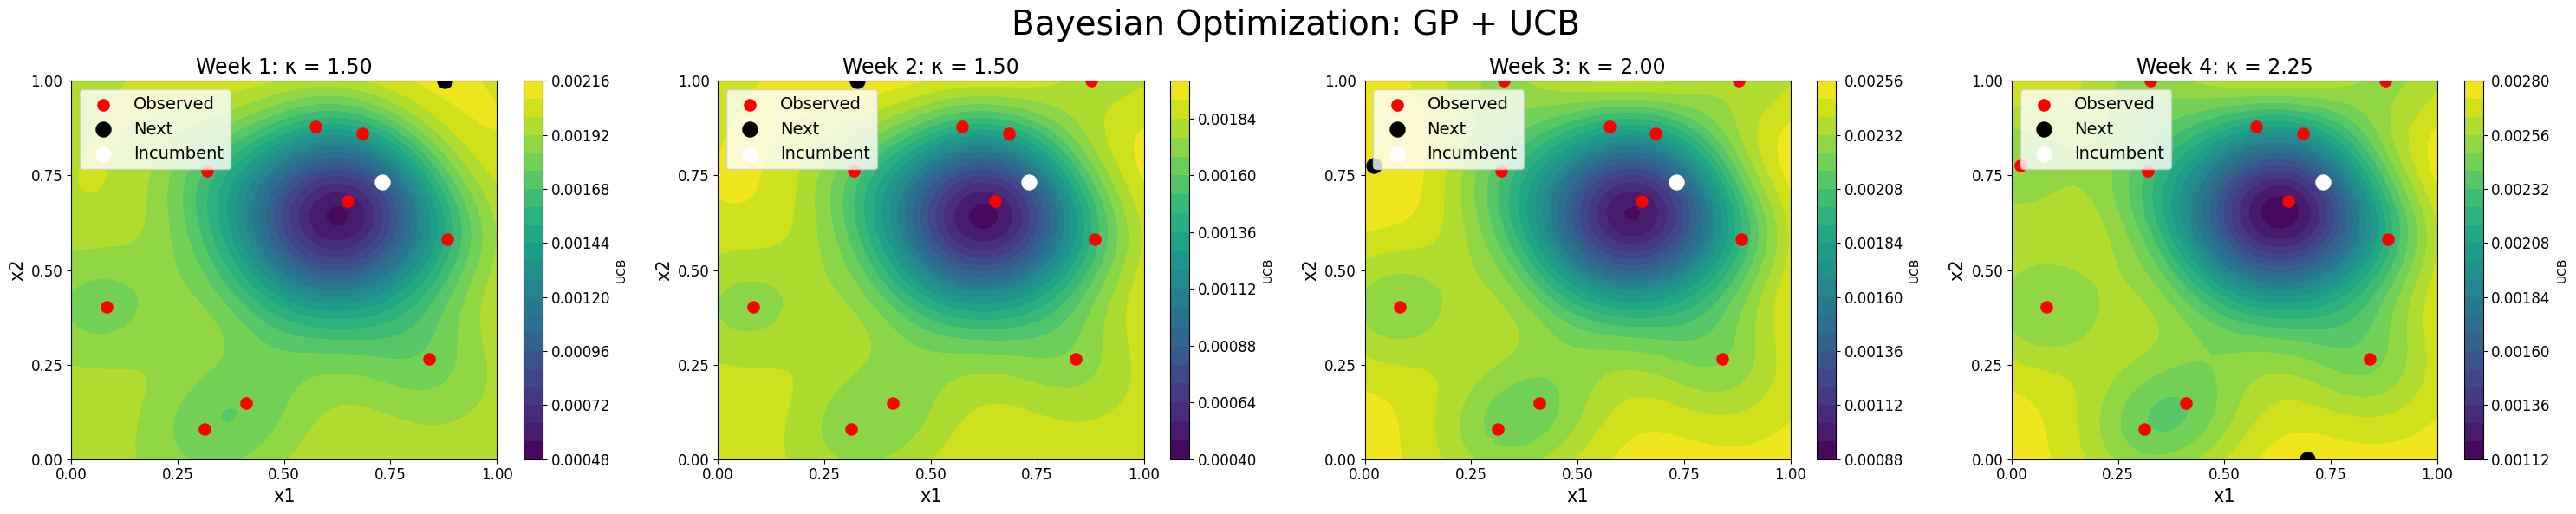

In [26]:
fig, axes = plt.subplots(1,4, figsize=(30, 6))

for week, ax  in enumerate(axes, start=1):

    week_data = data[:10 + week - 1]
    week_inputs, week_outputs = extract(week_data)
    week_incumbent = week_inputs[np.argmax(week_outputs)]
    week_candidate = np.array([phase_1_rows[week - 1]["candidate_x1"],phase_1_rows[week - 1]["candidate_x2"]])
    
    plot_acquisition_2d(X_grid_50, phase_1_ucbs[week-1], week_data, week_incumbent, week_candidate , "UCB", ax=ax)
    ax.set_title(f"Week {week}: κ = {phase_1_kappa_schedule[week - 1][1]:.2f}", fontsize=17)

fig.suptitle(f'Bayesian Optimization: GP + UCB', fontsize=28) 
plt.tight_layout()
plt.show()

**Phase 1 result:** Increasing $\kappa$ changed the exploratory recommendation but none of the four global GP-UCB evaluations improved the initial incumbent. This supports a change from broad uncertainty-driven exploration to a more selective improvement-oriented strategy.

<h1 style="color:#0000CD;font-size:19px;"">3. Phase 2: Higher resolution search (Weeks 5-8)</h1>

**3.1 - Strategy change: RBF GP and EI**

After four non-improving global queries, three decisions are made:

- the candidate resolution increases from $50^2$ to $500^2$ points;
- the RBF length scale is allowed to optimise within bounds $(0.05,1.0)$ rather than remaining fixed;
- UCB is replaced by **Expected Improvement (EI)**, putting more emphasis on exploitation around the current best value;

The practical effect is a more improvement-oriented search with a finer view of promising regions.

**Length-scale constraint:** The lower bound of 0.05 on the normalised domain acts as regularisation: the GP can adapt locally but cannot fit arbitrarily short-scale structure. The sensitivity of this modelling choice is tested retrospectively in the evaluation section.

**3.2 - Exploratory surface diagnostic**

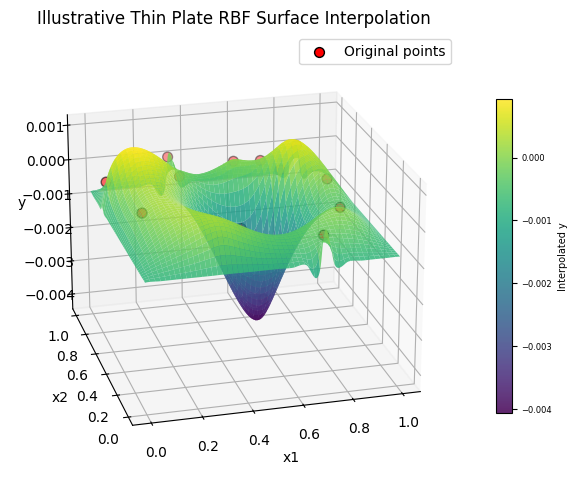

In [27]:
# Exploratory surface diagnostic only — not used for candidate selection
plot_rbf_surface_3d(data)

The RBF interpolation above is used only as a **qualitative diagnostic** of possible structure under sparse observations; it does not determine the queried point. It helps visualise possible local structure, but candidate selection still comes from the Gaussian Process and EI acquisition function.

**3.3. Phase 2 Loop**

In [28]:
X_grid_500 = cartesian_grid(dimension=2, points_per_axis=500)
rbf_bounded_kernel = RBF(length_scale=0.2, length_scale_bounds=(0.05, 1.0)) + WhiteKernel(noise_level=1e-6)

phase_2_rows = []
phase_2_eis = []

for week in range(5,9):

    inputs, outputs = extract(data)
    
    proposed_point, ei_values = run_search_strategy(
        inputs,
        outputs,
        X_grid_500,
        rbf_bounded_kernel,
        expected_improvement,
        best=np.max(outputs))

    queried_point, observed_y = historical_record(FUNCTION_ID, week)

    phase_2_rows.append({
        "week": week,
        "candidate_x1": proposed_point[0],
        "candidate_x2": proposed_point[1],
        "recorded_x1": queried_point[0],
        "recorded_x2": queried_point[1],
        "observed_y": observed_y,
        "matches_record": np.allclose(proposed_point, queried_point, atol=1e-6),
        "improved_incumbent": observed_y > outputs.max()})

    phase_2_eis.append(ei_values)
    data = update_data(data,queried_point,observed_y)

inputs, outputs = extract(data)
phase_2_history = pd.DataFrame(phase_2_rows)
display(phase_2_history)
    

Point added!
Point added!
Point added!
Point added!


,week,candidate_x1,candidate_x2,recorded_x1,recorded_x2,observed_y,matches_record,improved_incumbent
0,5,0.765531,0.763527,0.765531,0.763527,1.750000e-26,True,False
1,6,0.783567,0.699399,0.783567,0.699399,-1.230000e-20,True,False
2,7,0.330661,0.156313,0.330661,0.156313,8.810000e-56,True,False
3,8,0.639279,0.929860,0.639279,0.929860,1.070000e-63,True,False


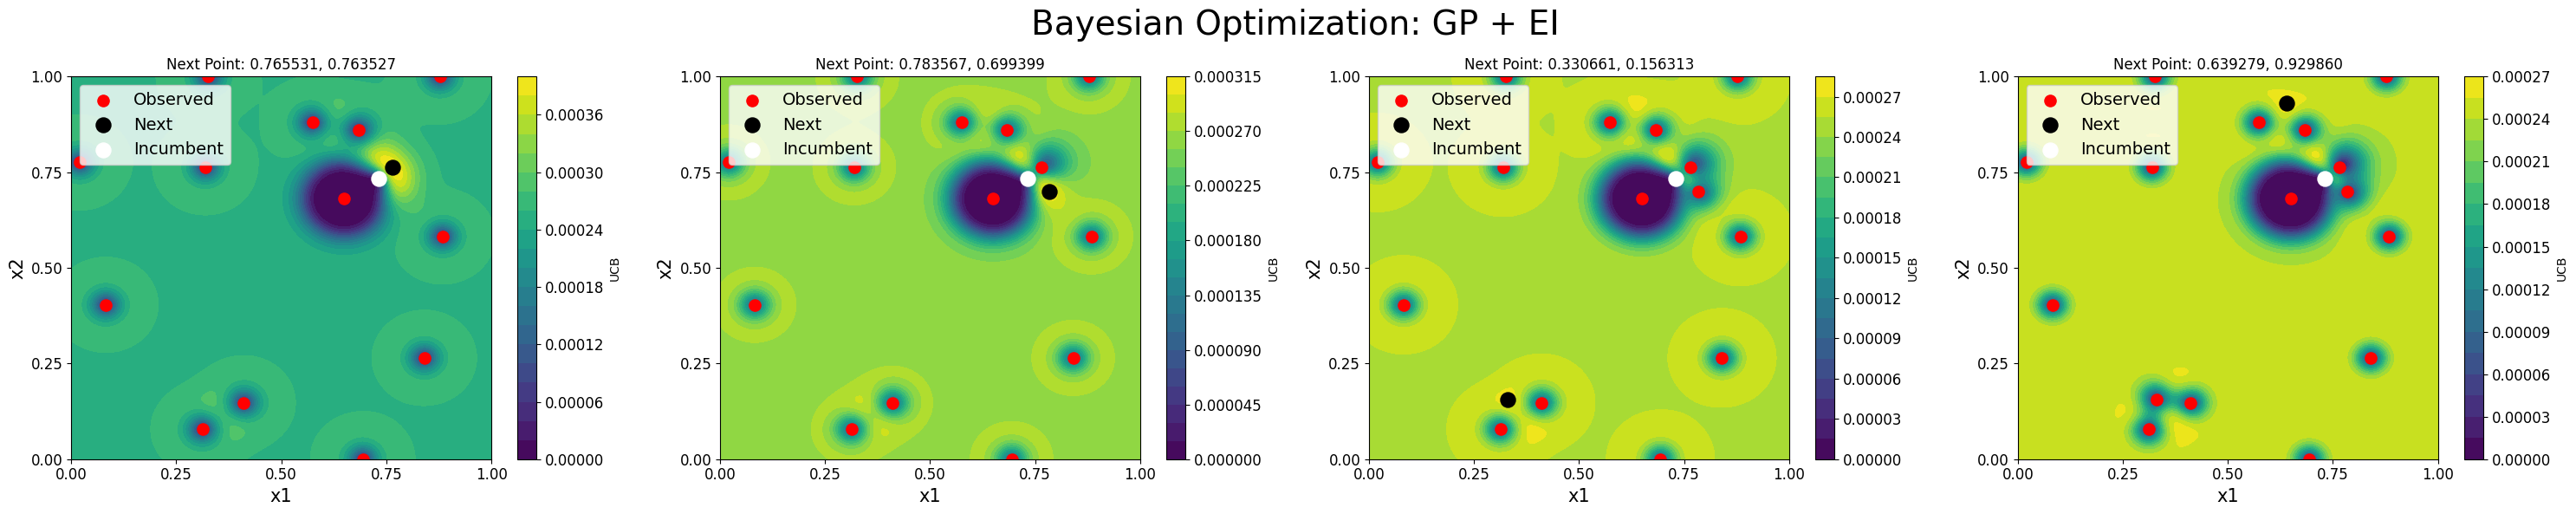

In [29]:
fig, axes = plt.subplots(1,4, figsize=(30, 6))

for week, ax  in enumerate(axes, start=5):

    week_data = data[:10 + week - 1]
    week_inputs, week_outputs = extract(week_data)
    week_incumbent = week_inputs[np.argmax(week_outputs)]
    week_candidate = np.array([phase_2_rows[week - 5]["candidate_x1"],phase_2_rows[week - 5]["candidate_x2"]])
    plot_acquisition_2d(X_grid_500, phase_2_eis[week-5], week_data, week_incumbent, week_candidate , "EI", ax=ax)

fig.suptitle(f'Bayesian Optimization: GP + EI', fontsize=28) 
plt.tight_layout()
plt.show()

**Phase 2 result:** The higher-resolution EI search found points with stronger local promise than the earlier exploratory queries, but none exceeded the initial incumbent. Further unrestricted global search now appears less attractive than concentrating the remaining budget near the strongest observed region. The strategy therefore moves to local refinement.

<h1 style="color:#0000CD;font-size:19px;"">4. Phase 3: Local refinement (Weeks 9-11)</h1>

**4.1. Local Matérn-PI exploitation**

With five evaluations remaining, the search is restricted to a small region around the current best observation:

- The surrogate switches to a **Matérn-3/2 kernel**, which allows more local variation than the smoother RBF specification.
- The acquisition function changes from Expected Improvement (EI) to **Probability of Improvement (PI)**, focusing the search on nearby points likely to improve on the incumbent.
- The local-search radius is then adjusted sequentially: **0.005 → 0.010 → 0.002** to first probe the neighbourhood and then concentrate the final search more tightly.

**4.2. Visualising transition from Global EI to Local PI**

Week 9 local PI candidate: [0.731124 0.733063]


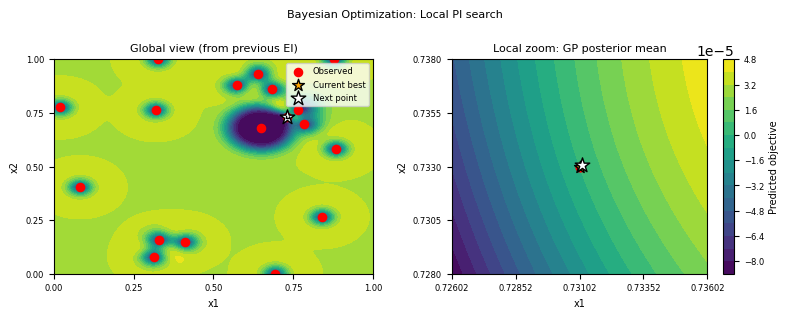

In [30]:
# Matern Local configuration
matern_32_kernel = ConstantKernel(1.0, (1e-6, 1e6))* Matern(length_scale=np.array([0.0025, 0.0025]), length_scale_bounds=(1e-4, 0.05), nu=1.5)
local_gp_kwargs = {"alpha": 1e-12, "normalize_y": True, "n_restarts_optimizer": 20, "random_state": RANDOM_SEED}

# Week 9 - Transition from global EI to local PI
inputs, outputs = extract(data)
x_best = inputs[np.argmax(outputs)]
lower, upper = search_region(x_best, radius=0.005)

local_candidates = random_candidates(
    dimension=inputs.shape[1],
    n_candidates=50_000,
    seed=RANDOM_SEED,
    lower=lower,
    upper=upper)

week_9_candidate, _ = run_search_strategy(
    inputs,
    outputs,
    local_candidates,
    matern_32_kernel,
    probability_of_improvement,
    gp_kwargs=local_gp_kwargs,
    best=outputs.max(),
    xi=0.0)

print(f"Week 9 local PI candidate: {week_9_candidate}")

# Local grid used only for visualisation
X_local_grid = cartesian_grid(dimension=2, points_per_axis=300, lower=lower, upper=upper)
local_gp = GaussianProcessRegressor( kernel=matern_32_kernel,**local_gp_kwargs)
local_gp.fit(inputs, outputs)
mu_local, _ = local_gp.predict(X_local_grid,return_std=True)

grid_size = int(np.sqrt(len(X_local_grid)))
mu_surface = mu_local.reshape(grid_size, grid_size)

# Final global EI landscape from the end of Phase 2
_, final_global_ei = run_search_strategy(
    inputs,
    outputs,
    X_grid_500,
    rbf_bounded_kernel,
    expected_improvement,
    best=outputs.max(),
    xi=0.0)

plot_global_to_local_refinement_2d(
    X_grid_500,
    final_global_ei,
    X_local_grid,
    mu_surface,
    data,
    lower,
    upper,
    week_9_candidate)

In [31]:
phase_3_radius_schedule = [(9, 0.005),(10, 0.010),(11, 0.002)]
phase_3_rows = []

for week, radius in phase_3_radius_schedule:

    inputs, outputs = extract(data)

    x_best = inputs[np.argmax(outputs)]
    lower, upper = search_region(x_best, radius)

    candidates = random_candidates(
        dimension=inputs.shape[1],
        n_candidates=50_000,
        seed=RANDOM_SEED,
        lower=lower,
        upper=upper)

    proposed_point, _ = run_search_strategy(
        inputs,
        outputs,
        candidates,
        matern_32_kernel,
        probability_of_improvement,
        gp_kwargs=local_gp_kwargs,
        best=outputs.max(),
        xi=0.0)

    queried_point, observed_y = historical_record(FUNCTION_ID,week)

    phase_3_rows.append({
        "week": week,
        "radius": radius,
        "candidate_x1": proposed_point[0],
        "candidate_x2": proposed_point[1],
        "recorded_x1": queried_point[0],
        "recorded_x2": queried_point[1],
        "observed_y": observed_y,
        "matches_record": np.allclose(
            proposed_point,
            queried_point,
            atol=1e-6),
        "improved_incumbent": observed_y > outputs.max()})

    data = update_data(
        data,
        queried_point,
        observed_y)

inputs, outputs = extract(data)

phase_3_history = pd.DataFrame(phase_3_rows)
display(phase_3_history)

Point added!
Point added!
Point added!


,week,radius,candidate_x1,candidate_x2,recorded_x1,recorded_x2,observed_y,matches_record,improved_incumbent
0,9,0.005,0.731124,0.733063,0.731124,0.733063,7.230000e-16,True,False
1,10,0.010,0.740979,0.733546,0.740979,0.733546,7.470000e-18,True,False
2,11,0.002,0.731064,0.733025,0.731064,0.733025,7.520000e-16,True,False


**Phase 3 result:**  Week 9 produced the strongest sequential result so far, although it remained below the incumbent. Expanding the local radius in Week 10 produced a much weaker value, while contracting it again in Week 11 returned a value close to the incumbent.

The useful structure therefore appears highly local. The final two evaluations focus even more tightly on the direction suggested by the strongest nearby observations.

<h1 style="color:#0000CD;font-size:19px;"">5. Phase 4: Directional refinement (Weeks 12-13)</h1>

With only two evaluations remaining, the strongest nearby observations suggested improvement toward the south-west of the incumbent. The final evaluations therefore used deterministic local probes in that direction rather than fitting another acquisition step.

In [32]:
phase_4_directional_probes = [ (12, [0.731010, 0.732975]),
                               (13, [0.730950, 0.732920]) ]

phase_4_rows = []

for week, proposed_point in phase_4_directional_probes:
    
    inputs, outputs = extract(data)
    queried_point, observed_y = historical_record(FUNCTION_ID,week)

    phase_4_rows.append({
        "week": week,
        "candidate_x1": proposed_point[0],
        "candidate_x2": proposed_point[1],
        "recorded_x1": queried_point[0],
        "recorded_x2": queried_point[1],
        "observed_y": observed_y,
        "matches_record": np.allclose(proposed_point, queried_point, atol=1e-6),
        "improved_incumbent": observed_y > outputs.max()})

    data = update_data(data, queried_point, observed_y)

inputs, outputs = extract(data)
phase_4_history = pd.DataFrame(phase_4_rows)
display(phase_4_history)

Point added!
Point added!


,week,candidate_x1,candidate_x2,recorded_x1,recorded_x2,observed_y,matches_record,improved_incumbent
0,12,0.73101,0.732975,0.73101,0.732975,7.830000e-16,True,True
1,13,0.73095,0.732920,0.73095,0.732920,8.190000e-16,True,True


**Final observed solution.** Both directional probes improved the incumbent. The best observed point is **[0.730950, 0.732920]** with $y=8.190854\times10^{-16}$. The remaining sections evaluate how much the query budget improved performance and how sensitive the main conclusions are to modelling and search-design choices.

<h1 style="color:#0000CD;font-size:19px;"">6. Quantitative Evaluation</h1>

The retrospective evaluation addresses three questions:

1. **Performance** — Did the 13-query budget improve the best observed objective?
2. **Surrogate robustness** — Do the main predictive conclusions depend materially on the assumed surrogate specification?
3. **Sensitivity / decision stability** — Would reasonable modelling or optimisation-design choices have materially changed what was queried?

Because the hidden objective function is no longer available, the analysis is restricted to the observed data and historical candidate-selection states. These checks are retrospective and were not used to select the historical queries.

**6.1 - Sequential and query-budget performance**

Each query is compared with the best value available immediately beforehand, showing when the additional evaluation budget actually improved the observed optimum.

,metric,value
0,Initial incumbent,7.710875114502849e-16
1,Final best observed,8.19e-16
2,Absolute improvement,4.791248854971509e-17
3,Relative improvement,6.21%
4,Queries improving incumbent,2


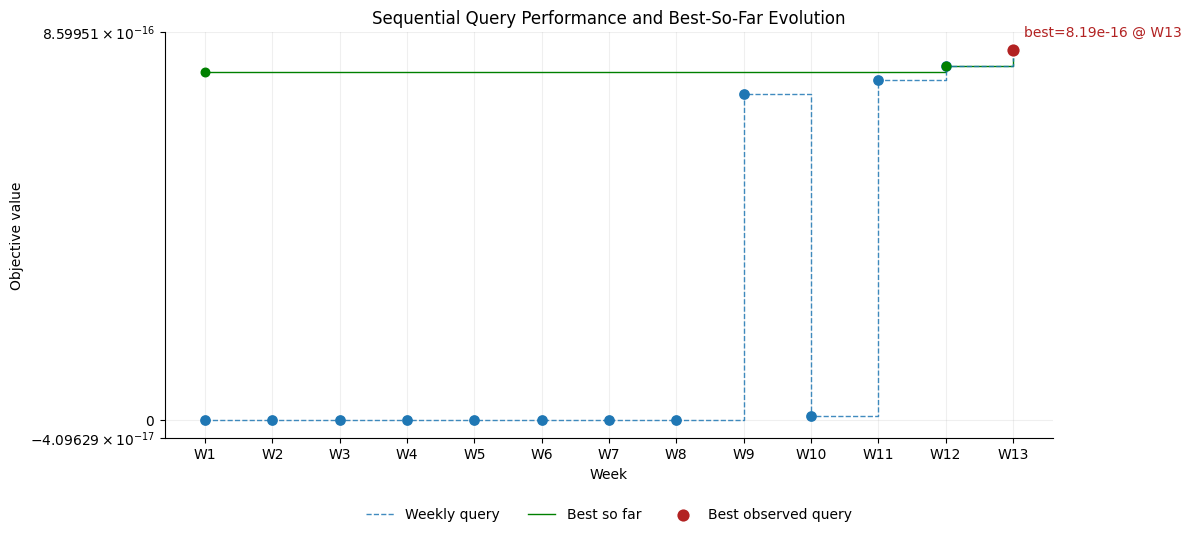

In [33]:
performance, performance_summary = sequential_performance(
    initial_outputs=outputs[:10],
    query_outputs=outputs[10:])

summary_display = performance_summary.copy()
summary_display["value"] = [
    f"{performance_summary.loc[0, 'value']}",
    f"{performance_summary.loc[1, 'value']}",
    f"{performance_summary.loc[2, 'value']}",
    f"{performance_summary.loc[3, 'value']:.2%}",
    f"{int(performance_summary.loc[4, 'value'])}"]

display(summary_display)
plot_sequential_query_performance(performance, FUNCTION_ID)

**Result.** The experiment started from an already strong incumbent and improved it by approximately **6.21%**. Only **2 of the 13** sequential queries directly improved the incumbent, both during the final directional-refinement stage.

The earlier global and improvement-search phases still played an important role: they tested broader regions and progressively supported concentrating the remaining budget locally.

**6.2 - Surrogate robustness**

Three GP kernel specifications are compared: fixed RBF, bounded RBF and Matérn-3/2. 

- **LOOCV RMSE** is used for predictive error <br>
- **Spearman correlation** is used for ranking stability<br>

In [34]:
predictive_kernels = {
    "RBF_fixed": RBF(length_scale=0.2, length_scale_bounds="fixed") + WhiteKernel(noise_level=1e-6),
    "RBF_bounded": RBF(length_scale=0.2, length_scale_bounds=(0.05, 1.0)) + WhiteKernel(noise_level=1e-6),
    "Matern_32": ConstantKernel(1.0, (1e-6, 1e6)) * Matern(length_scale=np.array([0.0025, 0.0025]), length_scale_bounds=(1e-4, 0.05), nu=1.5)}

surrogate_robustness = kernel_choice_validation(
    inputs,
    outputs,
    predictive_kernels,
    alpha=1e-10,
    normalize_y=True,
    n_restarts_optimizer=5,
    random_state=RANDOM_SEED)

display(surrogate_robustness)

,kernel,LOOCV_RMSE,Spearman_rank_correlation
0,RBF_fixed,0.000785,-0.645257
1,RBF_bounded,0.000766,0.538538
2,Matern_32,0.000761,0.516798


**Kernel robustness:**
- Aggregate LOOCV RMSE is similar across the tested surrogate specifications, suggesting that overall predictive error is relatively robust to kernel choice.
- However, ranking behaviour is not robust: the fixed RBF produces negative Spearman correlation, whereas the bounded RBF and Matérn-3/2 produce positive correlations. Kernel choice therefore matters more for preserving the ranking of observations than for aggregate predictive error.

**6.3 - Length-scale sensitivity**

Sensitivity is tested in the form used by each phase:

- fixed RBF length scales in Weeks 1-4;
- RBF initial values and bounds in Weeks 5-8;
- Matérn initial values and bounds in Weeks 9-11.

The **initial value** affects where hyperparameter optimisation starts; the **bounds** restrict the range of smoothness the fitted model can ultimately choose.

In [35]:
# 1. Fixed RBF — start of Week 1
phase_1_inputs = inputs[:10]
phase_1_outputs = outputs[:10]

def fixed_rbf_kernel(length_scale):
    return build_kernel("rbf", phase_1_inputs.shape[1], length_scale, "fixed")

fixed_rbf_sensitivity = fixed_length_scale_validation(
    phase_1_inputs,
    phase_1_outputs,
    kernel_factory=fixed_rbf_kernel,
    length_scales=[0.05, 0.10, 0.20, 0.40],
    alpha=1e-10,
    normalize_y=True)

print("Fixed RBF")
display(fixed_rbf_sensitivity)

# 2. Bounded RBF — start of Week 5
phase_2_inputs = inputs[:14]
phase_2_outputs = outputs[:14]

def fitted_rbf_kernel(initial_scale, bounds):
    return build_kernel("rbf", phase_2_inputs.shape[1], initial_scale, bounds)

rbf_sensitivity = length_scale_cv_sensitivity(
    phase_2_inputs,
    phase_2_outputs,
    kernel_factory=fitted_rbf_kernel,
    historical_initial_scale=0.2,
    historical_bounds=(0.05, 1.0),
    initial_scales=[0.10, 0.20, 0.50],
    bounds_to_test=[(0.01, 1.0), (0.05, 1.0), (0.10, 1.0)],
    alpha=1e-10,
    normalize_y=True,
    n_restarts_optimizer=0,
    random_state=RANDOM_SEED)

print("Bounded RBF")
display(rbf_sensitivity)

# 3. Bounded Matérn-3/2 — start of Week 9
phase_3_inputs = inputs[:18]
phase_3_outputs = outputs[:18]

def fitted_matern_kernel(initial_scale, bounds):
    return build_kernel("matern", phase_3_inputs.shape[1], initial_scale, bounds, 1.5)

matern_sensitivity = length_scale_cv_sensitivity(
    phase_3_inputs,
    phase_3_outputs,
    kernel_factory=fitted_matern_kernel,
    historical_initial_scale=[0.0025, 0.0025],
    historical_bounds=(1e-4, 0.05),
    initial_scales=[[0.001, 0.001], [0.0025, 0.0025], [0.005, 0.005]],
    bounds_to_test=[(1e-5, 0.05), (1e-4, 0.05), (1e-3, 0.05), (1e-4, 0.10)],
    alpha=1e-12,
    normalize_y=True,
    n_restarts_optimizer=20,
    random_state=RANDOM_SEED)

print("Matérn-3/2")
display(matern_sensitivity)

Fixed RBF


,length_scale,LOOCV_RMSE,Spearman_rank_correlation
0,0.05,0.001225,-0.284848
1,0.10,0.001368,-0.442424
2,0.20,0.001286,-0.878788
3,0.40,0.001261,-0.939394


Bounded RBF


,test,initial_scale,bounds,LOOCV_RMSE,Spearman_rank_correlation
0,Initialisation,0.1,"(0.05, 1.0)",0.001099,-0.265934
1,Initialisation,0.2,"(0.05, 1.0)",0.001099,-0.265934
2,Initialisation,0.5,"(0.05, 1.0)",0.001099,-0.265934
3,Bounds,0.2,"(0.01, 1.0)",0.001000,-0.609449
4,Bounds,0.2,"(0.05, 1.0)",0.001099,-0.265934
5,Bounds,0.2,"(0.1, 1.0)",0.001142,-0.529670


Matérn-3/2


,test,initial_scale,bounds,LOOCV_RMSE,Spearman_rank_correlation
0,Initialisation,"[0.001, 0.001]","(0.0001, 0.05)",0.000875,0.192982
1,Initialisation,"[0.0025, 0.0025]","(0.0001, 0.05)",0.000875,0.192982
2,Initialisation,"[0.005, 0.005]","(0.0001, 0.05)",0.000875,0.192982
3,Bounds,"[0.0025, 0.0025]","(1e-05, 0.05)",0.000876,0.161074
4,Bounds,"[0.0025, 0.0025]","(0.0001, 0.05)",0.000875,0.192982
5,Bounds,"[0.0025, 0.0025]","(0.001, 0.05)",0.000878,-0.091847
6,Bounds,"[0.0025, 0.0025]","(0.0001, 0.1)",0.000899,-0.188854


**A few observations:** 
- Fixed-RBF predictive error changes little across reasonable fixed length scales, although ranking performance remains  weak. Spearman correlation remains negative across every tested fixed length scale. Changing the fixed RBF length scale therefore does not resolve its poor ranking behaviour, although the severity of the disagreement varies with the scale.<br>

- For both optimised RBF and Matérn kernels, initialisation has negligible impact, whereas changing the admissible **bounds** materially affects ranking behaviour. Aggregate LOOCV RMSE remains comparatively stable.

**6.4 - Optimisation-design sensitivity / decision stability**

The analysis tests whether reasonable changes to UCB $\kappa$, local-search radius and Cartesian grid resolution would move the recommended query to a qualitatively different region.

In [36]:
# UCB kappa sensitivity — Week 1 state
X_phase = inputs[:10]
y_phase = outputs[:10]

kernel = RBF(length_scale=0.2, length_scale_bounds="fixed") + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(X_phase, y_phase)

mu, sigma = gp.predict(X_grid_50, return_std=True)
kappa_values = [1.0, 1.5, 2.0, 2.25, 2.5]

kappa_points = {}
for kappa in kappa_values:
    scores = upper_confidence_bound(mu, sigma, kappa)
    kappa_points[kappa] = X_grid_50[np.argmax(scores)]

reference_point = kappa_points[1.5]
kappa_sensitivity = pd.DataFrame([{ 
    "kappa": kappa,
    "candidate_x1": point[0],
    "candidate_x2": point[1],
    "distance_from_kappa_1.5": np.linalg.norm(point - reference_point)}
    for kappa, point in kappa_points.items() ])

display(kappa_sensitivity.style.format({
    "kappa": "{:.2f}",
    "candidate_x1": "{:.4f}",
    "candidate_x2": "{:.4f}",
    "distance_from_kappa_1.5": "{:.4f}"}))

,kappa,candidate_x1,candidate_x2,distance_from_kappa_1.5
0,1.00,0.8367,1.0000,0.0408
1,1.50,0.8776,1.0000,0.0000
2,2.00,0.9184,1.0000,0.0408
3,2.25,0.9184,1.0000,0.0408
4,2.50,0.9388,1.0000,0.0612


In [37]:
# Local trust-region radius sensitivity — Week 9 state
X_phase = inputs[:18]
y_phase = outputs[:18]
x_best = X_phase[np.argmax(y_phase)]
y_best = np.max(y_phase)

kernel = ConstantKernel(1.0, (1e-6, 1e6)) * Matern(
    length_scale=np.array([0.0025, 0.0025]),
    length_scale_bounds=(1e-4, 0.05),
    nu=1.5)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-12,
    normalize_y=True,
    n_restarts_optimizer=20,
    random_state=RANDOM_SEED)

gp.fit(X_phase, y_phase)

radius_results = []
for radius in [0.0025, 0.0050, 0.0100, 0.0200]:
    lower, upper = search_region(x_best, radius=radius)
    candidates = random_candidates(
        dimension=2,
        n_candidates=50_000,
        seed=RANDOM_SEED,
        lower=lower,
        upper=upper)
    
    mu, sigma = gp.predict(candidates, return_std=True)
    pi = probability_of_improvement(mu, sigma, y_best, xi=0.0)
    candidate = candidates[np.argmax(pi)]
    displacement = np.linalg.norm(candidate - x_best)

    radius_results.append({
        "radius": radius,
        "candidate_x1": candidate[0],
        "candidate_x2": candidate[1],
        "distance_to_incumbent": displacement,
        "relative_displacement": displacement / radius,
        "max_PI": np.max(pi)})

radius_sensitivity = pd.DataFrame(radius_results)
display(radius_sensitivity.style.format({
    "radius": "{:.4f}",
    "candidate_x1": "{:.6f}",
    "candidate_x2": "{:.6f}",
    "distance_to_incumbent": "{:.6f}",
    "relative_displacement": "{:.3f}",
    "max_PI": "{:.3f}"}))

,radius,candidate_x1,candidate_x2,distance_to_incumbent,relative_displacement,max_PI
0,0.0025,0.731074,0.733032,0.000060,0.024,0.613
1,0.0050,0.731124,0.733063,0.000119,0.024,0.613
2,0.0100,0.731225,0.733127,0.000238,0.024,0.613
3,0.0200,0.731240,0.733086,0.000233,0.012,0.612


In [38]:
# Cartesian candidate-resolution sensitivity — Week 1 UCB
X_phase = inputs[:10]
y_phase = outputs[:10]

kernel = RBF(length_scale=0.2, length_scale_bounds="fixed") + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(X_phase, y_phase)

cartesian_sensitivity = cartesian_resolution_sensitivity(
    gp=gp,
    dimension=2,
    resolutions=[25, 50, 100, 250],
    acquisition="UCB",
    best=np.max(y_phase),
    kappa=1.5)

cartesian_sensitivity[["candidate_x1", "candidate_x2"]] = pd.DataFrame(
    cartesian_sensitivity["candidate"].tolist(),
    index=cartesian_sensitivity.index)

reference_candidate = cartesian_sensitivity.loc[cartesian_sensitivity["resolution"] == 50, "candidate"].iloc[0]
cartesian_sensitivity["distance_from_50²"] = cartesian_sensitivity["candidate"].apply(
    lambda point: np.linalg.norm(point - reference_candidate))

candidate_resolution_sensitivity = cartesian_sensitivity[[
    "resolution",
    "n_candidates",
    "candidate_x1",
    "candidate_x2",
    "distance_from_50²",
    "acquisition_max"]]

display(candidate_resolution_sensitivity.style.format({
    "resolution": "{}²",
    "n_candidates": "{:,}",
    "candidate_x1": "{:.6f}",
    "candidate_x2": "{:.6f}",
    "distance_from_50²": "{:.6f}",
    "acquisition_max": "{:.6e}"}))

,resolution,n_candidates,candidate_x1,candidate_x2,distance_from_50²,acquisition_max
0,25²,625,0.875000,1.000000,0.002551,2.101305e-03
1,50²,"2,500",0.877551,1.000000,0.000000,2.101393e-03
2,100²,"10,000",0.878788,1.000000,0.001237,2.101418e-03
3,250²,"62,500",0.879518,1.000000,0.001967,2.101428e-03


**Results:** 
- Reasonable changes in $\kappa$ move the UCB recommendation gradually within the same exploratory region.<br>
- Local-radius perturbations retain the same neighbourhood around the incumbent, and increasing Cartesian resolution refines rather than qualitatively relocates the Week 1 recommendation.<br>
- Candidate selection is therefore reasonably stable to the tested optimisation-design choices.<br>

<h1 style="color:#0000CD;font-size:19px;"">7. Conclusions and Limitations</h1>

Function 1 improved the initial incumbent by approximately **6.21%** within 13 additional evaluations. The two improvements occurred only after the search moved from broad exploration to very local refinement.

The optimisation path was therefore: broad exploration did not beat the incumbent; the higher-resolution EI phase tested a more improvement-oriented global search but still failed to improve the incumbent; local Matérn-PI then concentrated the search around the incumbent; and the final directional probes produced the two incumbent improvements.

The retrospective checks support that narrative. Predictive error is similar across plausible kernels, ranking is more model-sensitive, and length-scale bounds matter more than initialisation. Reasonable changes to $\kappa$, local-search radius and candidate resolution do not materially alter the selected search region.

**Limitation:** The final point is the **best observed configuration under the available query budget**, not proof of the global maximum.